<a href="https://colab.research.google.com/github/joplus2/MPA-MLF/blob/main/PC3/MPA_MLF_PCA_2_students.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PCA through Singular Value Decomposition

tři body, vektor 3*2 (X,Y), body jsou korelované, možnost uvažovat jednu dimenzi, což ušetří zdroje
\
\
nutno vypočítat koherentní matici z bodů x
\
$R = (1/n)*x*x'$
\
nutno udělat matici U s bází
\
$Y = P . X$ ; kde $P$ je projektovaná X, $Y$ jsou nová data
\
\
Pouze u1 nese důležitou info, u2 můžeme nulovat, nese malá data
\
Díky ortogonalitě je transponované matice U vynásobená originální jednotkovou maticí ... tak se vypaří (?)

In [3]:
import numpy as np
# Defined 3 points in 2D-space:
X=np.array([[2, 1, 0],[4, 3, 0]])
# Calculate the covariance matrix:
R = np.matmul(X,X.T)/3

# Calculate the SVD decomposition and new basis vectors:
[U,D,V]=np.linalg.svd(R)  # call SVD decomposition
u1=U[:,0] # new basis vectors
u2=U[:,1]

print("u1 = ",u1)
print("u2 = ",u2)
u2 = np.zeros((1, 2))
print("u2 = ",u2)
# Calculate the coordinates in new orthonormal basis:
X_proj = np.dot(U.T, X)
print(X_proj)

# Calculate the approximation of the original from new basis
#print(Xi1[:,None]) # add second dimention to array and test it


# Check that you got the original
X_reconstructed = np.dot(U, X_proj)
print(X_reconstructed)

u1 =  [-0.40455358 -0.9145143 ]
u2 =  [-0.9145143   0.40455358]
u2 =  [[0. 0.]]
[[-4.46716435 -3.14809647  0.        ]
 [-0.21081425  0.29914646  0.        ]]
[[2. 1. 0.]
 [4. 3. 0.]]


# PCA on Iris data

Iris data jsou uložena v X, má targety ....
** něco něco **
\
\
KNN klasifikátor rozhodující o tom kam patří bod na základě barvy sousedů - většina sousedů barva zelená -> pak je zelená
\
KNN aplikujeme na $X_{PCA}$ ale jen se dvěmi features, eliminujeme feture s nejvyšší rozmanitostí
\
Pak aplikujeme KNN na původní data $X_{PP}$ a eliminujeme jednu feature

In [4]:
# Load Iris dataset as in the last PC lab:
from sklearn.datasets import load_iris
iris=load_iris()
iris.feature_names
print(iris.feature_names)
print(iris.data[0:5,:])
print(iris.target[:])

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


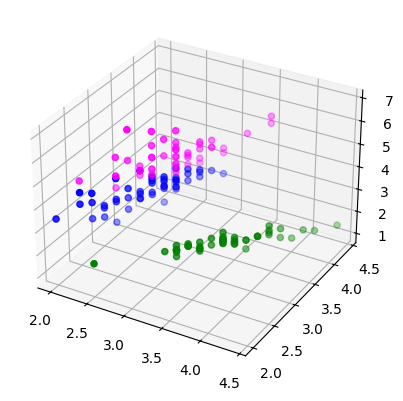

In [6]:
# We have 4 dimensions of data, plot the first three colums in 3D
X=iris.data
y=iris.target
import matplotlib.pyplot as plt
axes1=plt.axes(projection='3d')
axes1.scatter3D(X[y==0,1],X[y==0,1],X[y==0,2],color='green')
axes1.scatter3D(X[y==1,1],X[y==1,1],X[y==1,2],color='blue')
axes1.scatter3D(X[y==2,1],X[y==2,1],X[y==2,2],color='magenta')
plt.show()


[[ 0.05290845 -0.00491134  0.05999602  0.05975355]
 [-0.00491134  0.03298254 -0.02328082 -0.02111795]
 [ 0.05999602 -0.02328082  0.08952249  0.09149784]
 [ 0.05975355 -0.02111795  0.09149784  0.10086914]]


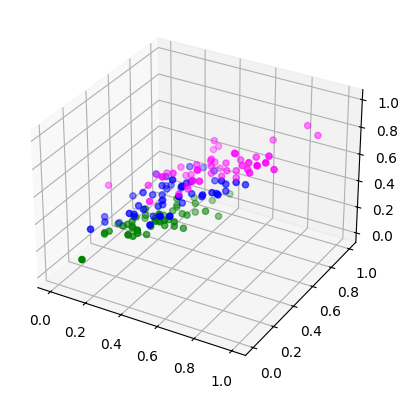

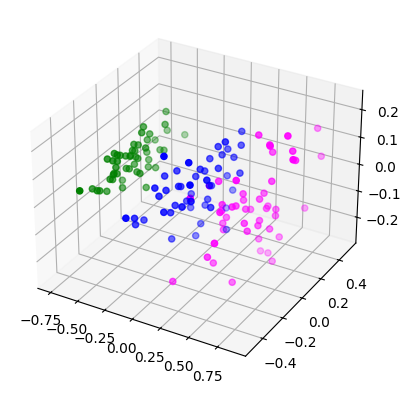

0.44055555555555553


In [15]:
# Pre-processing is an important step, you can try either StandardScaler (zero mean, unit variance of features)
# or MinMaxScaler (to interval from 0 to 1)
from sklearn import preprocessing, decomposition
from sklearn.preprocessing import StandardScaler, MinMaxScaler
#Xscaler = StandardScaler()
Xscaler = MinMaxScaler()
Xpp=Xscaler.fit_transform(X)

# define PCA object (three components), fit and transform the data
pca = decomposition.PCA(n_components=3)
pca.fit(Xpp)
Xpca = pca.transform(Xpp)
print(pca.get_covariance())
# you can plot the transformed feature space in 3D:
axes2=plt.axes(projection='3d')
axes2.scatter3D(Xpp[y==0,0],Xpp[y==0,1],Xpp[y==0,2],color='green')
axes2.scatter3D(Xpp[y==1,0],Xpp[y==1,1],Xpp[y==1,2],color='blue')
axes2.scatter3D(Xpp[y==2,0],Xpp[y==2,1],Xpp[y==2,2],color='magenta')
plt.show()

axes3=plt.axes(projection='3d')
axes3.scatter3D(Xpca[y==0,0],Xpca[y==0,1],Xpca[y==0,2],color='green')
axes3.scatter3D(Xpca[y==1,0],Xpca[y==1,1],Xpca[y==1,2],color='blue')
axes3.scatter3D(Xpca[y==2,0],Xpca[y==2,1],Xpca[y==2,2],color='magenta')
plt.show()

print(np.mean(Xpp[:,1]))


In [16]:
# Compute pca.explained_variance_ and pca.explained_cariance_ratio_values
pca.explained_variance_

array([0.23245325, 0.0324682 , 0.00959685])

In [17]:
pca.explained_variance_ratio_

array([0.84136038, 0.11751808, 0.03473561])

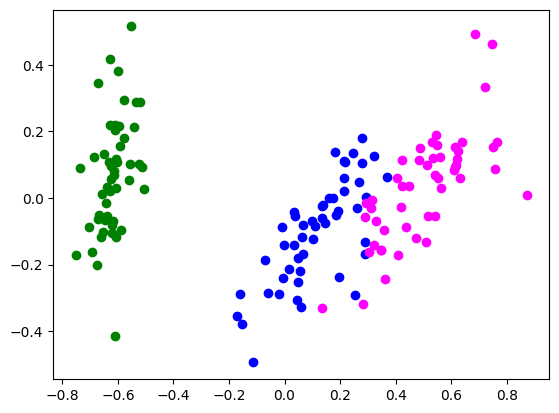

In [18]:
# Plot the principal components in 2D, mark different targets in color
plt.scatter(Xpca[y == 0,0], Xpca[y == 0,1], color = 'green', label= 'Classe 0')
plt.scatter(Xpca[y == 1,0], Xpca[y == 1,1], color = 'blue', label= 'Classe 1')
plt.scatter(Xpca[y == 2,0], Xpca[y == 2,1], color = 'magenta', label= 'Classe 2')
plt.show()

# KNN classifier

Datasety X_train a Y_train jsou pro trénování a zbytek pro testování (test_size = 0.3 je 30% testing a 70 training (?) )

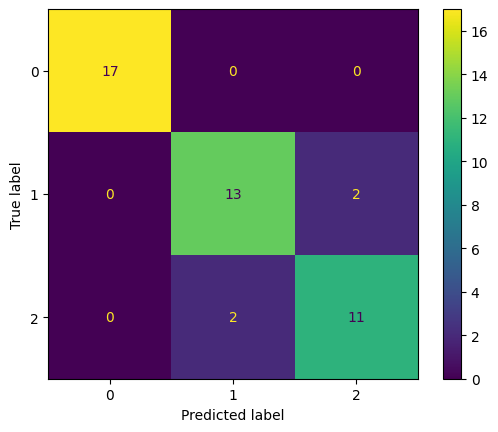

In [20]:
# Import train_test_split as in last PC lab, split X (original) into train and test, train KNN classifier on full 4-dimensional X

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

X_train, X_test, Y_train, Y_test = train_test_split(Xpp, y, test_size=0.3)

knn1=KNeighborsClassifier(n_neighbors = 3)
knn1.fit(X_train, Y_train)
Ypred=knn1.predict(X_test)

# Import and show confusion matrix
confusion_matrix(Y_test, Ypred)
ConfusionMatrixDisplay.from_predictions(Y_test, Ypred)



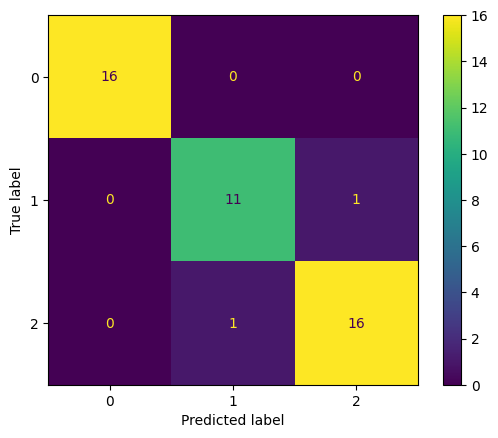

In [21]:
# Now do the same (data set split, KNN, confusion matrix), but for PCA-transformed data (1st two principal components, i.e., first two columns).
# Compare the results with full dataset
X_train, X_test, Y_train, Y_test = train_test_split(Xpca, y, test_size=0.3)

knn1=KNeighborsClassifier(n_neighbors = 3)
knn1.fit(X_train, Y_train)
Ypred=knn1.predict(X_test)

# Import and show confusion matrix
confusion_matrix(Y_test, Ypred)
ConfusionMatrixDisplay.from_predictions(Y_test, Ypred)

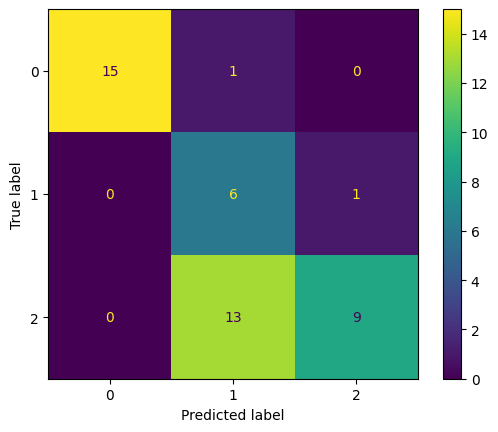

In [38]:
# Now do the same, but use only 2-dimensional data of original X (first two columns)
X_train, X_test, Y_train, Y_test = train_test_split(X[:, 0:2], y, test_size=0.3)

knn1=KNeighborsClassifier(n_neighbors = 3)
knn1.fit(X_train, Y_train)
Ypred=knn1.predict(X_test)

# Import and show confusion matrix
confusion_matrix(Y_test, Ypred)
ConfusionMatrixDisplay.from_predictions(Y_test, Ypred)